In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

**IMPORTING THE LIBRARIES**

In [3]:
pip install yfinance


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 1.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")
%matplotlib inline

# For reading stock data from yahoo
import yfinance as yf
from datetime import datetime

yf.pdr_override()

# The tech stocks that is used for this analysis
tech_list = ['AAPL']

# Set up End and Start times for data grab
tech_list = ['AAPL']

start = datetime(2013, 1, 1)  # Start date: January 1, 2013
end = datetime(2023, 7, 31)   # End date: July 31, 2023

for stock in tech_list:
    globals()[stock] = yf.download(stock, start, end)

company_list = [AAPL]
company_name = ["APPLE"]

for company, com_name in zip(company_list, company_name):
    company["company_name"] = com_name
df = pd.concat(company_list, axis=0)
df.tail(10)


/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume,company_name
Date,,,,,,,
2023-07-17,191.899994,194.320007,191.809998,193.990005,193.728394,50520200,APPLE
2023-07-18,193.350006,194.330002,192.419998,193.729996,193.468735,48353800,APPLE
2023-07-19,193.100006,198.229996,192.649994,195.100006,194.836899,80507300,APPLE
2023-07-20,195.089996,196.470001,192.500000,193.130005,192.869553,59581200,APPLE
2023-07-21,194.100006,194.970001,191.229996,191.940002,191.681168,71917800,APPLE
2023-07-24,193.410004,194.910004,192.250000,192.750000,192.490067,45377800,APPLE
2023-07-25,193.330002,194.440002,192.919998,193.619995,193.358887,37283200,APPLE
2023-07-26,193.669998,195.639999,193.320007,194.500000,194.237701,47471900,APPLE
2023-07-27,196.020004,197.199997,192.550003,193.220001,192.959427,47460200,APPLE


In [5]:
df.head()

,Open,High,Low,Close,Adj Close,Volume,company_name
Date,,,,,,,
2013-01-02,19.779285,19.821428,19.343929,19.608213,16.791185,560518000,APPLE
2013-01-03,19.567142,19.631071,19.321428,19.360714,16.579241,352965200,APPLE
2013-01-04,19.177500,19.236786,18.779642,18.821428,16.117439,594333600,APPLE
2013-01-07,18.642857,18.903570,18.400000,18.710714,16.022627,484156400,APPLE
2013-01-08,18.900356,18.996071,18.616072,18.761070,16.065744,458707200,APPLE


**APPLE STOCK STATISTICS**

In [6]:
AAPL.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2661.000000,2661.000000,2661.000000,2661.000000,2661.000000,2.661000e+03
mean,67.877312,68.636464,67.164994,67.932532,65.983549,1.654415e+08
std,52.846973,53.500814,52.251383,52.908234,53.359676,1.242180e+08
min,13.856071,14.271429,13.753571,13.947500,12.013332,3.145820e+07
25%,27.307501,27.590000,27.084999,27.340000,25.020508,8.744960e+07
50%,43.125000,43.529999,42.794998,43.125000,41.099827,1.256428e+08
75%,121.650002,123.349998,120.010002,121.260002,119.490875,1.995884e+08
max,196.020004,198.229996,194.139999,195.830002,195.565918,1.460852e+09


In [7]:
AAPL.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2661 entries, 2013-01-02 to 2023-07-28
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          2661 non-null   float64
 1   High          2661 non-null   float64
 2   Low           2661 non-null   float64
 3   Close         2661 non-null   float64
 4   Adj Close     2661 non-null   float64
 5   Volume        2661 non-null   int64  
 6   company_name  2661 non-null   object 
dtypes: float64(5), int64(1), object(1)
memory usage: 166.3+ KB


**Historical Closing Price **

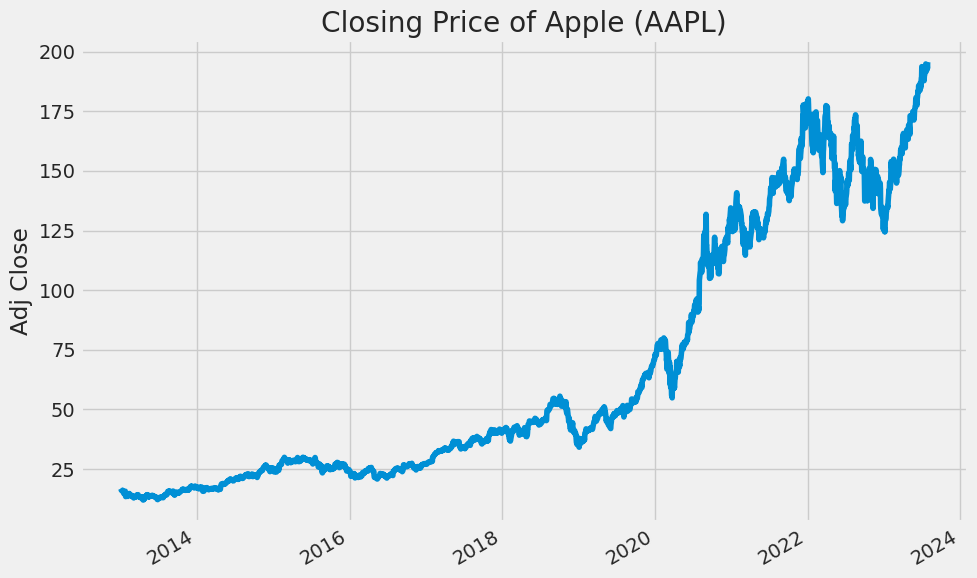

In [8]:
# Historical view of the closing price
plt.figure(figsize=(10, 6))

AAPL['Adj Close'].plot()
plt.ylabel('Adj Close')
plt.xlabel(None)
plt.title("Closing Price of Apple (AAPL)")

plt.tight_layout()
plt.show()


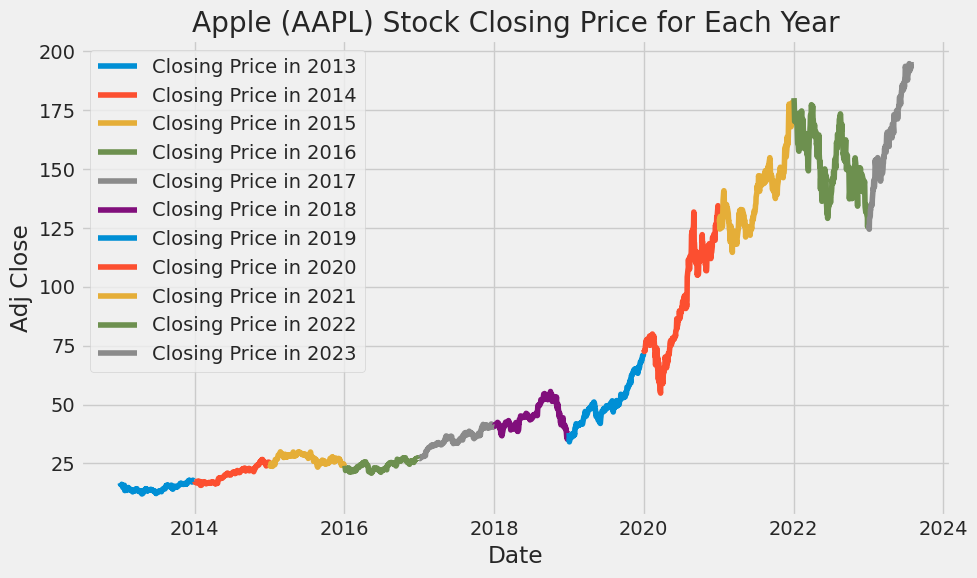

In [9]:
plt.figure(figsize=(10, 6))

years = AAPL.index.year.unique()  # Get unique years from the index

for year in years:
    year_data = AAPL[AAPL.index.year == year]
    plt.plot(year_data.index, year_data['Adj Close'], label=f'Closing Price in {year}')

plt.title('Apple (AAPL) Stock Closing Price for Each Year')
plt.xlabel('Date')
plt.ylabel('Adj Close')
plt.legend()
plt.tight_layout()
plt.show()

**Exploratory Data Analytics**

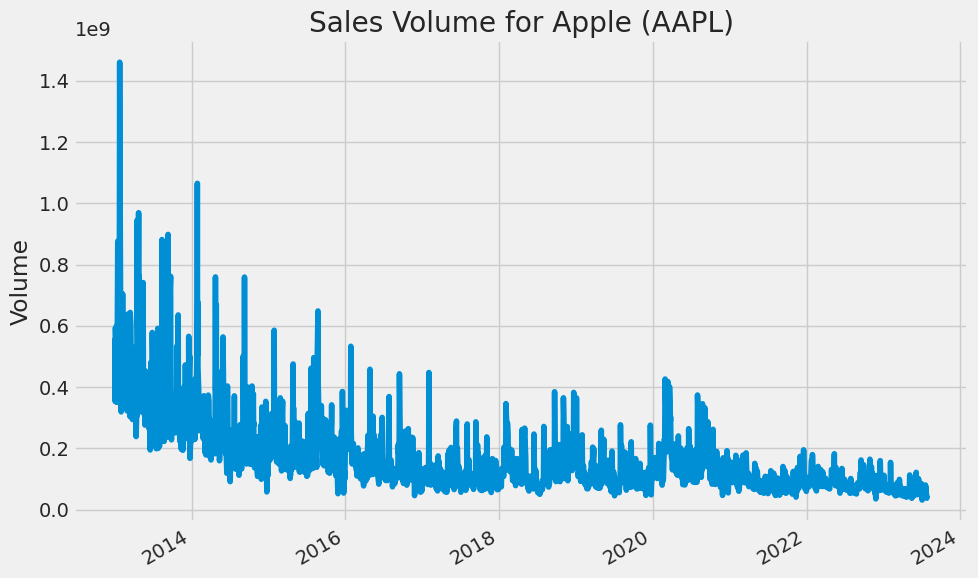

In [10]:
# Now the total volume of stock being traded each day for Apple (AAPL)
plt.figure(figsize=(10, 6))

AAPL['Volume'].plot()
plt.ylabel('Volume')
plt.xlabel(None)
plt.title("Sales Volume for Apple (AAPL)")

plt.tight_layout()
plt.show()

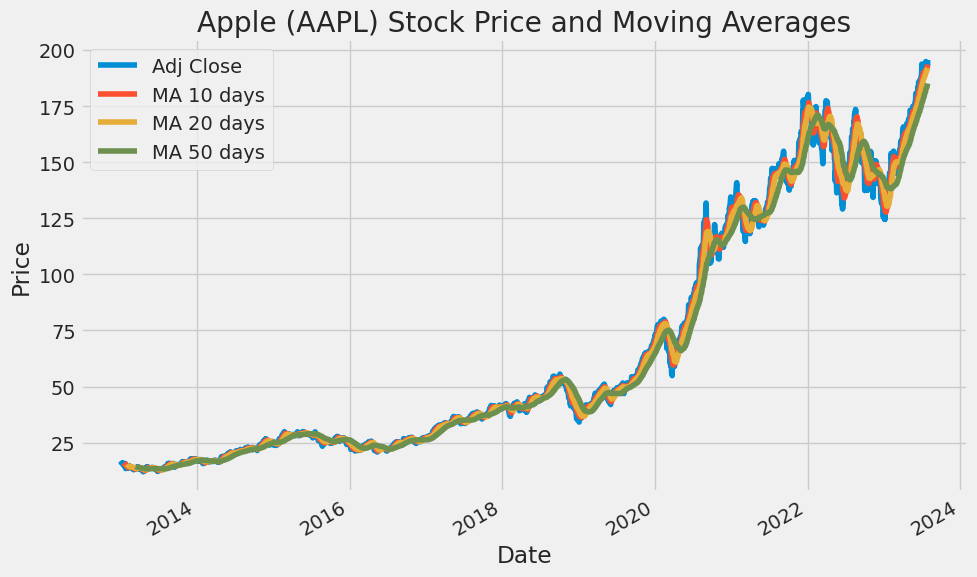

In [11]:
ma_day = [10, 20, 50]

for ma in ma_day:
    for company in company_list:
        column_name = f"MA for {ma} days"
        company[column_name] = company['Adj Close'].rolling(ma).mean()
        

fig, axes = plt.subplots(nrows=1, ncols=1)
fig.set_figheight(6)
fig.set_figwidth(10)

AAPL[['Adj Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes)
axes.set_title('Apple (AAPL) Stock Price and Moving Averages')
axes.set_xlabel('Date')
axes.set_ylabel('Price')
axes.legend(['Adj Close', 'MA 10 days', 'MA 20 days', 'MA 50 days'])

plt.tight_layout()
plt.show()


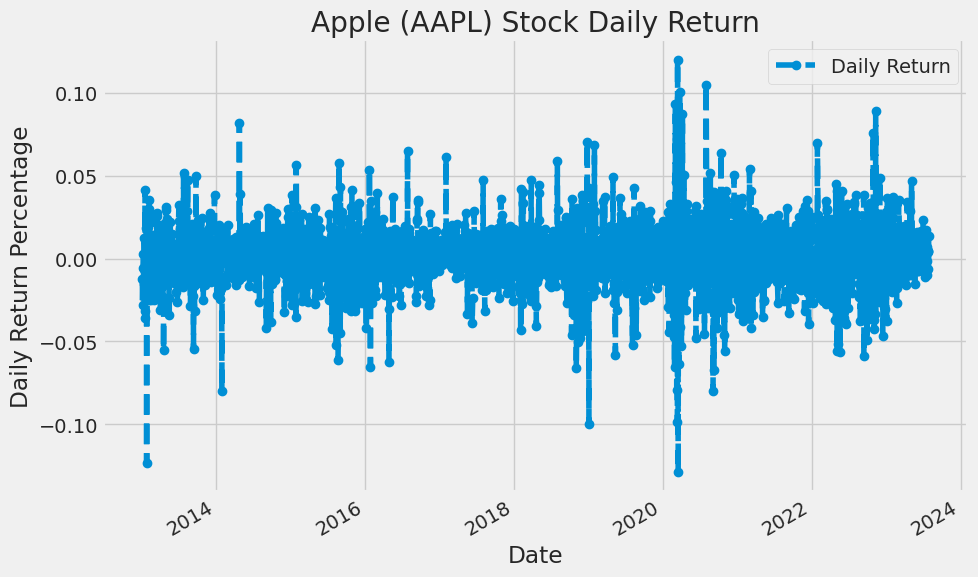

In [12]:
#  use pct_change to find the percent change for each day
for company in company_list:
    company['Daily Return'] = company['Adj Close'].pct_change()

#  plot the daily return percentage
fig, axes = plt.subplots(nrows=1, ncols=1)
fig.set_figheight(6)
fig.set_figwidth(10)

AAPL['Daily Return'].plot(ax=axes, legend=True, linestyle='--', marker='o')
axes.set_title('Apple (AAPL) Stock Daily Return')
axes.set_xlabel('Date')
axes.set_ylabel('Daily Return Percentage')

plt.tight_layout()
plt.show()


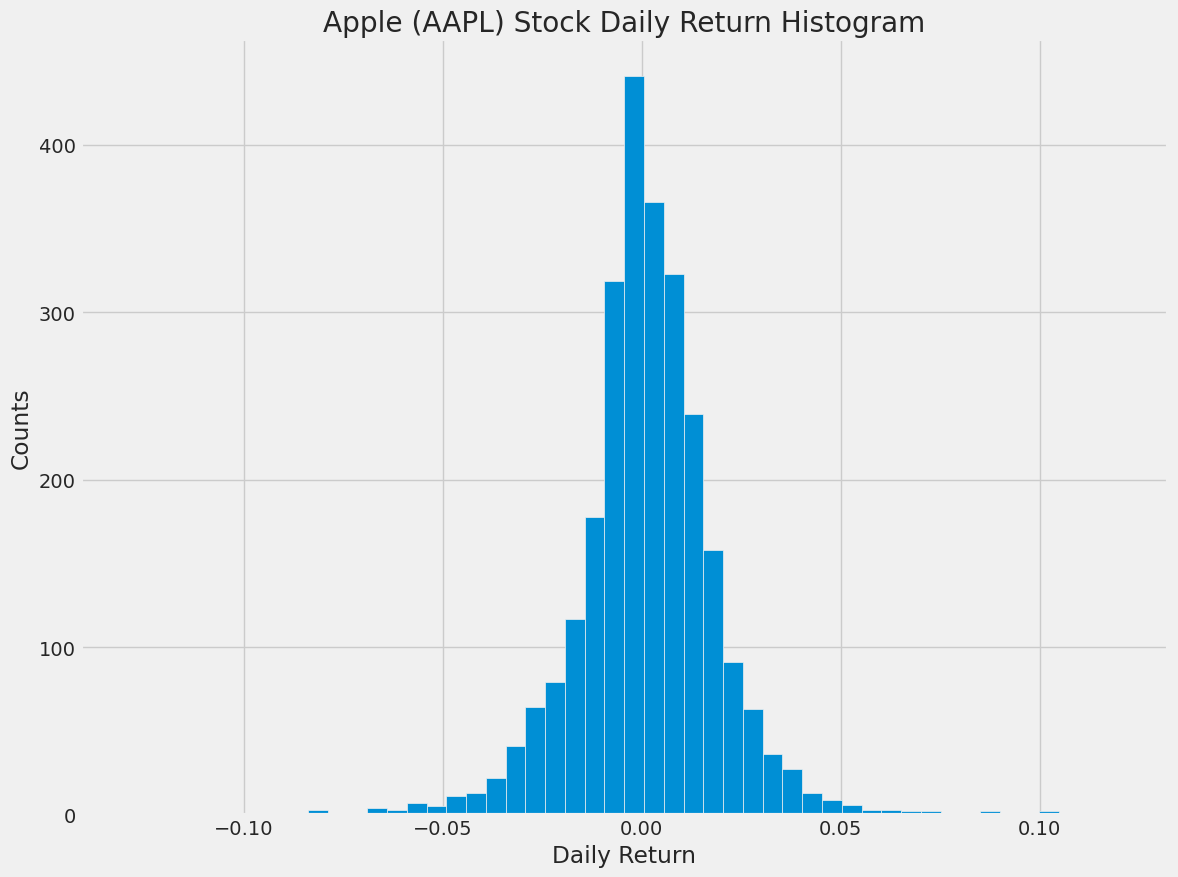

In [13]:
plt.figure(figsize=(12, 9))

AAPL['Daily Return'].hist(bins=50)
plt.xlabel('Daily Return')
plt.ylabel('Counts')
plt.title('Apple (AAPL) Stock Daily Return Histogram')

plt.tight_layout()
plt.show()


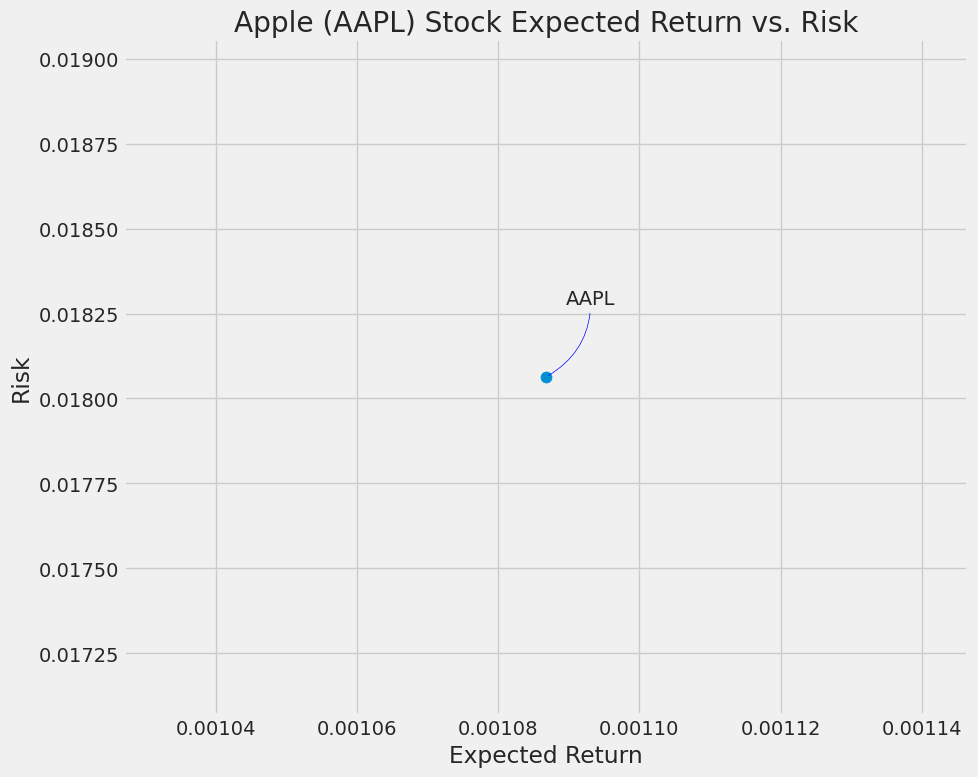

In [14]:
rets = AAPL['Daily Return'].dropna()

area = np.pi * 20

plt.figure(figsize=(10, 8))
plt.scatter(rets.mean(), rets.std(), s=area)
plt.xlabel('Expected Return')
plt.ylabel('Risk')

plt.annotate('AAPL', xy=(rets.mean(), rets.std()), xytext=(50, 50), textcoords='offset points',
             ha='right', va='bottom', arrowprops=dict(arrowstyle='-', color='blue', connectionstyle='arc3,rad=-0.3'))

plt.title('Apple (AAPL) Stock Expected Return vs. Risk')
plt.tight_layout()
plt.show()


In [15]:
# Create a new dataframe with only the 'Close column 
data = df.filter(['Close'])
# Convert the dataframe to a numpy array
dataset = data.values
# Get the number of rows to train the model on
training_data_len = int(np.ceil( len(dataset) * .95 ))

training_data_len

2528

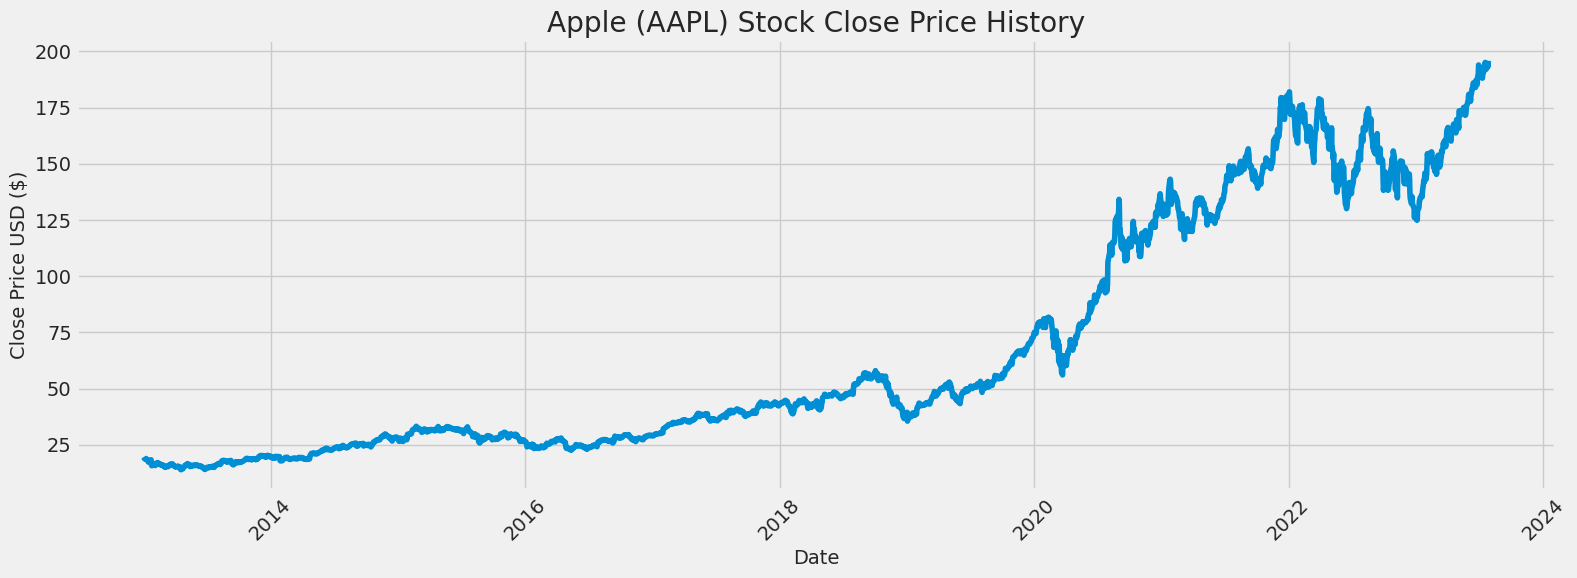

In [16]:
plt.figure(figsize=(16, 6))
plt.title('Apple (AAPL) Stock Close Price History')

plt.plot(df['Close'])
plt.xlabel('Date', fontsize=14)
plt.ylabel('Close Price USD ($)', fontsize=14)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

plt.tight_layout()
plt.show()


**Scale and Training**

In [17]:
# Create the training data set 
# Create the scaled training data set
# Assuming you have 'dataset' as your original data

# Import necessary libraries
from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler(feature_range=(0, 1))

# Scale the data
scaled_data = scaler.fit_transform(dataset)

# Set the training data length
training_data_len = int(np.ceil(len(scaled_data) * 0.95))

# Create the training data set
train_data = scaled_data[0:int(training_data_len), :]


train_data = scaled_data[0:int(training_data_len), :]
# Split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<= 61:
        print(x_train)
        print(y_train)
        print()
        
# Convert the x_train and y_train to numpy arrays 
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
# x_train.shape

[array([0.03112291, 0.02976215, 0.02679712, 0.02618841, 0.02646527,
       0.02485317, 0.02611184, 0.02548153, 0.02183906, 0.0187307 ,
       0.02269125, 0.02202167, 0.02149543, 0.02243206, 0.02424642,
       0.01177566, 0.00969032, 0.01164409, 0.01330136, 0.01301861,
       0.01275549, 0.01238829, 0.01016944, 0.01321693, 0.01312072,
       0.01525514, 0.01658253, 0.0175545 , 0.0151923 , 0.01501754,
       0.01493507, 0.01367249, 0.0136391 , 0.01145166, 0.01090382,
       0.01183653, 0.01026369, 0.01147523, 0.01061124, 0.00998879,
       0.00784258, 0.00579652, 0.00797414, 0.00689809, 0.00786418,
       0.00808803, 0.00929564, 0.00744201, 0.0074263 , 0.00824119,
       0.01043256, 0.01280065, 0.01255913, 0.0120859 , 0.01221353,
       0.01401611, 0.01434403, 0.01386492, 0.0120859 , 0.0102362 ])]
[0.007536262012825187]

[array([0.03112291, 0.02976215, 0.02679712, 0.02618841, 0.02646527,
       0.02485317, 0.02611184, 0.02548153, 0.02183906, 0.0187307 ,
       0.02269125, 0.02202167, 0.0

**LSTM MODEL**

In [18]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

# Build the LSTM model
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape= (x_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(x_train, y_train, batch_size=1, epochs=1)

/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl6StatusC1EN10tensorflow5error4CodeESt17basic_string_viewIcSt11char_traitsIcEENS_14SourceLocationE']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so: undefined symbol: _ZTVN10tenso

2468/2468 [==============================] - 86s 33ms/step - loss: 0.0012


**Model Evaluvation**

In [20]:
# Create the testing data set
# Create a new array containing scaled values from index 1543 to 2002 
test_data = scaled_data[training_data_len - 60: , :]
# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])
    
# Convert the data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

# Get the models predicted price values 
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse


5/5 [==============================] - 0s 30ms/step


2.8105034151861203

/tmp/ipykernel_32/2388977846.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


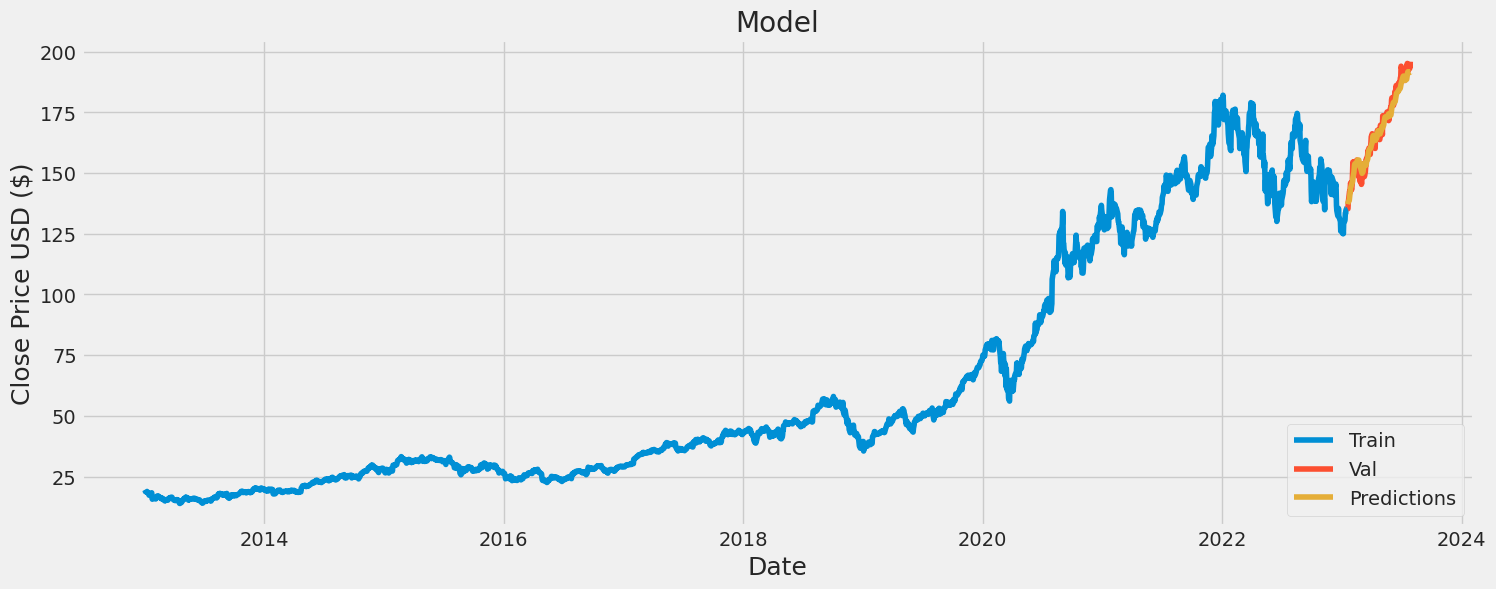

In [21]:
# Plot the data
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions
# Visualize the data
plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

In [22]:
# Show the valid and predicted prices
valid

,Close,Predictions
Date,,
2023-01-18,135.210007,137.150375
2023-01-19,135.270004,137.739822
2023-01-20,137.869995,138.067474
2023-01-23,141.110001,138.723480
2023-01-24,142.529999,139.987961
...,...,...
2023-07-24,192.750000,191.518036
2023-07-25,193.619995,191.335312
2023-07-26,194.500000,191.363144
